In [102]:
#set the environment variable for Groq API key
import os

if "GROQ_API_KEY" not in os.environ:
    print("Warning: GROQ_API_KEY environment variable not set")


In [103]:
#Now llm setup
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)


Define a Graph

create a llm schema

In [104]:
#llm schema choose the different topics from the user input

from pydantic import BaseModel,Field
from typing import  List

class llm_schema(BaseModel):
    topic : List[str] = Field(description="select the topic on the basis of user query.")



In [105]:
llm_with_schema = llm.with_structured_output(llm_schema)

llm_with_schema.invoke("what is the capital of France and total population of France?")

llm_schema(topic=['Capital of France', 'Population of France'])

create a graph schema

In [106]:
from typing import TypedDict,List

class Graph_Schema(TypedDict):
    input: str
    topic: list[str]
    results: []
    summary: []

Create a Graph node -> Orchestrator Node

In [107]:
# orchestrator node ley user input ligxa ani llm schema lai input pathauxa ani llm schema ley topic  return garxa 

def Orchestrator_node(state: Graph_Schema) -> Graph_Schema:
    user_input = state["input"]

    response = llm_with_schema.invoke(user_input)

    topic = response.topic

    #update state 
    state["topic"] = topic

    return state

Now create worker Node like in Architecture Diagram -> can see picture in the langgraph folder 

In [108]:
def execute_func(user_query: str):

    response = llm.invoke(user_query).content

    return response


In [109]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state: Graph_Schema) -> Graph_Schema:
    #in worker node, we need to create a multiple func as number of topics so each runs parallely.
    #parallel execution using multithreading process i.e use the python library concurrent.futures i.e ThreadPoolExecutor
    topic = state["topic"]
    results = []

    with ThreadPoolExecutor(max_workers=len(topic)) as executor:
        future = executor.map(execute_func,topic)
    #since future is iterable
    for item in future:
        results.append(item)

    #update state to results
    state["results"] = results

    return {"results": results}

Create a collector node that merge the response

In [110]:
#collector node summarize the responses from the worker node and return state
from langchain_core.prompts import ChatPromptTemplate

def collector_node(state: Graph_Schema) -> Graph_Schema:

    results = state["results"]

    #lets create a system propt to summarize the results
    prompt = ChatPromptTemplate.from_messages([
        ("system","you are a collector node that summarize the results from worker node."),
        ("user",f"Here are the results from worker: {results}. Please summarize each topic.")
        ]
    )



    #lets define a chain avoid the 2 time invoke
    chain = prompt | llm

    summary = chain.invoke({"results": results})
    #update the state
    state["summary"] = summary

    return state

Create a Graph state

In [111]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(Graph_Schema)

#lets add a node
graph.add_node("Orchestrator_node",Orchestrator_node)
graph.add_node("worker_node",worker_node)
graph.add_node("collector_node",collector_node)

#add the edges
graph.add_edge(START,"Orchestrator_node")
graph.add_edge("Orchestrator_node","worker_node")
graph.add_edge("worker_node","collector_node")
graph.add_edge("collector_node",END)


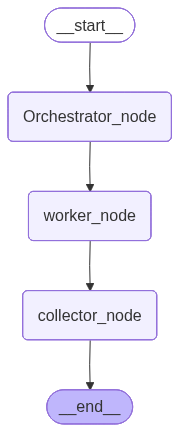

In [112]:
#lest compile the graph
from IPython.display import Image,display

orchestrator_graph = graph.compile()
Image(orchestrator_graph.get_graph().draw_mermaid_png())

In [113]:
#lets run the graph

orchestrator_graph.invoke({
    "input":"what is the capital of Nepal and What is the population of this cointry? and What is the second highest peak of world and who climb it first?",
    "topic": [],
    "results": [],
    "summary": "",
})

{'input': 'what is the capital of Nepal and What is the population of this cointry? and What is the second highest peak of world and who climb it first?',
 'topic': ['Nepal',
  'capital',
  'population',
  'second highest peak',
  'world',
  'first climber'],
 'results': ["Nepal is a country located in the Himalayas between India and China (Tibet). It is a federal democratic republic and has a rich cultural heritage. Here are some key facts about Nepal:\n\n**Geography:**\n\n- Nepal is a landlocked country, with a total area of 147,181 square kilometers.\n- It is home to the highest mountain in the world, Mount Everest (also known as Sagarmatha in Nepali and Chomolungma in Tibetan), which stands at 8,848 meters above sea level.\n- The country has a diverse geography, with the Himalayas in the north, the Terai in the south, and the Mahabharat range in between.\n\n**Culture:**\n\n- Nepal has a rich cultural heritage, with a mix of Hinduism and Buddhism.\n- The country is home to over 125 

In [114]:
from langchain_core.messages import HumanMessage
for chunk in orchestrator_graph.stream(
    {
    "input":"what is the capital of Nepal and What is the population of this cointry? and What is the second highest peak of world and who climb it first?",
    "topic": [],
    "results": [],
    "summary": "",
    },
    stream_mode = "updates"
):

    print(chunk)

{'Orchestrator_node': {'input': 'what is the capital of Nepal and What is the population of this cointry? and What is the second highest peak of world and who climb it first?', 'topic': ['Nepal capital', 'Nepal population', 'world second highest peak', 'world second highest peak first climber'], 'results': [], 'summary': ''}}
{'worker_node': {'results': ['The capital of Nepal is Kathmandu.', 'According to the World Bank and the United Nations, the estimated population of Nepal as of 2020 is approximately 31.5 million.', "The second-highest peak in the world is K2, also known as Mount Godwin-Austen or Chhogori. It is located on the border between Pakistan and China in the Karakoram range of the Himalayas.\n\nK2 has an elevation of 8,611 meters (28,251 feet) above sea level. It is considered one of the most challenging and dangerous mountains to climb due to its steep and exposed routes, unpredictable weather, and remote location.\n\nK2 was named after the second letter in the alphabet, 